In [45]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.services.indicators import avwap_func_nb, atr_trailing_nb

import numba
@numba.njit
def shift_numba(arr: np.ndarray, num: int, fill_value=np.nan):
    result = np.empty_like(arr)
    n_rows, n_cols = arr.shape
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n_rows - num, :]
    elif num < 0:
        result[num:, :] = fill_value
        result[:n_rows + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result

## Load datasource from deltalake and save it to local h5 file
# REMOTE_HOST = "http://192.168.1.30:9000"
REMOTE_HOST = "https://minio.phuchuynh.xyz"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
df

Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                        \
symbol           AAA        ABB        ACB        ACV       ADS        AGG   
date                                                                         
2016-01-29  6.892738   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-01  7.196829   8.201591   3.616231  20.629999  3.940815  15.284813   
2016-02-02  7.298193   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-03  7.196829   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-04  7.247511   8.201591   3.635365  20.629999  3.940815  15.284813   
...              ...        ...        ...        ...       ...        ...   
2026-01-21  7.970000  14.300000  24.850000  59.799999  8.240000  14.650000   
2026-01-22  8.110000  14.100000  24.850000  60.400002  8.220000  15.150000   
2026-01-23  8.000000  14.200000  25.049999  59.400002  8.300000  14.700000   
2026-01-26  7.810000  13.900000  24.799999  53.400002  8.220000  14.650000   
2026-01-27  7.800000  13.800000  24.700001  51.200001  8.150000  14.500000   

                                                       ...        volume  \
symbol            AGR        ANV        APH       ASM  ...       VNINDEX   
date                                                   ...                 
2016-01-29   2.744280  17.299999  30.166281  8.001494  ...  9.877289e+07   
2016-02-01   2.744280  17.299999  30.166281  7.954974  ...  9.151639e+07   
2016-02-02   2.561327  17.299999  30.166281  7.861933  ...  8.205790e+07   
2016-02-03   2.652804  17.299999  30.166281  7.861933  ...  7.248801e+07   
2016-02-04   2.561327  17.299999  30.166281  7.954974  ...  5.899160e+07   
...               ...        ...        ...       ...  ...           ...   
2026-01-21  16.150000  26.200001   6.440000  6.410000  ...  1.186887e+09   
2026-01-22  16.350000  26.799999   6.470000  6.440000  ...  9.453971e+08   
2026-01-23  16.250000  26.900000   6.390000  6.380000  ...  8.795579e+08   
2026-01-26  15.900000  27.150000   6.300000  6.270000  ...  1.102434e+09   
2026-01-27  15.950000  26.700001   6.300000  6.150000  ...  7.826771e+08   

                                                                    \
symbol             VNM        VOS         VPB       VPG        VPI   
date                                                                 
2016-01-29    178270.0    11700.0  58299312.0    5000.0     5000.0   
2016-02-01    865310.0     7000.0  58299312.0    5000.0     5000.0   
2016-02-02    251520.0     1730.0  58299312.0    5000.0     5000.0   
2016-02-03    269870.0     2030.0  58299312.0    5000.0     5000.0   
2016-02-04    257320.0    70230.0  58299312.0    5000.0     5000.0   
...                ...        ...         ...       ...        ...   
2026-01-21  11234100.0  1343000.0  34082700.0  205800.0  2018800.0   
2026-01-22   8055200.0  4522500.0  19795300.0   97700.0  1522200.0   
2026-01-23  16050400.0  3865500.0  31092900.0  134200.0  1268600.0   
2026-01-26   8864800.0  2987900.0  32470600.0   74600.0  1128700.0   
2026-01-27   8357800.0  1986600.0   7349400.0  136600.0  1404300.0   

                                                          
symbol             VRE         VSC        VTP        YEG  
date                                                      
2016-01-29       800.0    107040.0      300.0     6100.0  
2016-02-01       800.0    702150.0      300.0     6100.0  
2016-02-02       800.0    251650.0      300.0     6100.0  
2016-02-03       800.0    121570.0      300.0     6100.0  
2016-02-04       800.0    202610.0      300.0     6100.0  
...                ...         ...        ...        ...  
2026-01-21   6966700.0  16271000.0  1228500.0  4410300.0  
2026-01-22   7252900.0   8567000.0  1317800.0  2965300.0  
2026-01-23   7919100.0   9390200.0  1410100.0  2026800.0  
2026-01-26   6004100.0  12339600.0  1131100.0  1618300.0  
2026-01-27  10746100.0   5417100.0   815700.0   727900.0  

[2498 rows x 990 columns]

In [48]:
## Williams Vix Fix Formula
def williams_vix_fix_signal(close, high, low, period=22, mult=2.0,
    bbl: int = 20,
    lb: int = 50,
    ph: float = 0.85, # percentile high
    ltLB: int = 40,
    mtLB: int = 14,
    strength_str: int = 2):

    MAX = vbt.IndicatorFactory.from_talib("MAX")
    SMA = vbt.IndicatorFactory.from_talib("SMA")
    STDDEV = vbt.IndicatorFactory.from_talib("STDDEV")
    # 1) WVF
    highest_close = MAX.run(close, timeperiod=period).real
    wvf = ((highest_close - low) / highest_close) * 100.0

    # 2) Bands
    midLine = SMA.run(wvf, timeperiod=bbl).real
    sDev = STDDEV.run(wvf, timeperiod=bbl).real * mult
    upperBand = midLine + sDev
    rangeHigh = MAX.run(wvf, timeperiod=lb).real * ph

    # # 3) Conditions
    low_np = low.to_numpy()
    close_np = close.to_numpy()
    high_np = high.to_numpy()
    wvf_np = wvf.to_numpy()
    upperBand_np = upperBand.to_numpy()
    rangeHigh_np = rangeHigh.to_numpy()

    upRange = (low_np > shift_numba(low_np, 1)) & (close_np > shift_numba(high_np, 1))

    filtered = (
        ((shift_numba(wvf_np, 1) >= shift_numba(upperBand_np, 1)) | (shift_numba(wvf_np, 1) >= shift_numba(rangeHigh_np, 1)))
        & (wvf_np < upperBand_np)
        & (wvf_np < rangeHigh_np)
    )

    cond_FE = (
        upRange
        & (close_np > shift_numba(close_np, strength_str))
        & ((close_np < shift_numba(close_np, ltLB)) | (close_np < shift_numba(close_np, mtLB)))
        & filtered
    )

    cond = pd.DataFrame(cond_FE, index=close.index, columns=close.columns)
    return cond
     

def strategy_breakout_ttm(close, high, low, args):
    williams_vix_fix_signal_np = williams_vix_fix_signal(close, high, low, 
        period=args['william_vix_period'], mult=args['bb_multiplier'], bbl=args['bb_period'], 
        lb=args['lb'], ph=args['ph'], ltLB=args['ltLB'], mtLB=args['mtLB'], strength_str=args['strength_str'])

    buy_signal = williams_vix_fix_signal_np

    atr_trailing_real = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10).real
    atr_trailing_indicator = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing']
    ).from_apply_func(atr_trailing_nb)
    atr_sl = atr_trailing_indicator.run(close, atr_trailing_real, atr_multiplier=1.9)
    exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)

    ## Max low stoploss
    lowest_low = vbt.IndicatorFactory.from_talib("MIN").run(low, timeperiod=args['donichan_period']).real
    exit2 = close < shift_numba(lowest_low.to_numpy(), 1)
    sell_signal = exit1

    pf = vbt.Portfolio.from_signals(
        close=close, 
        entries=buy_signal, 
        exits=sell_signal, 
        freq='1d', 
        group_by=['symbol'],
        sl_stop=0.1,  # 10% hard stop loss
    )
    return pf

## Breakout strategy
close = df.close.copy().round(2)
high = df.high.copy().round(2)
low = df.low.copy().round(2)
args = {'bb_period': 10, 'bb_multiplier': 1.2, 'william_vix_period': 20, 'lb': 50, 'ph': 0.85, 'ltLB': 40, 'mtLB': 14, 'strength_str': 3, 'donichan_period': 10}
pf = strategy_breakout_ttm(close, high, low, args)

## set bet params
pf.stats()


Start                                 2016-01-29 00:00:00
End                                   2026-01-27 00:00:00
Period                                 2498 days 00:00:00
Start Value                                         100.0
End Value                                      215.361737
Total Return [%]                               115.361737
Benchmark Return [%]                           294.988276
Max Gross Exposure [%]                              100.0
Total Fees Paid                                       0.0
Max Drawdown [%]                                35.459668
Max Drawdown Duration         901 days 03:52:43.636363632
Total Trades                                    22.378788
Total Closed Trades                             22.227273
Total Open Trades                                0.151515
Open Trade PnL                                   1.589338
Win Rate [%]                                    46.889411
Best Trade [%]                                  50.142177
Worst Trade [%

In [49]:
pf['YEG'].stats()

Start                                2016-01-29 00:00:00
End                                  2026-01-27 00:00:00
Period                                2498 days 00:00:00
Start Value                                        100.0
End Value                                      155.42142
Total Return [%]                                55.42142
Benchmark Return [%]                          -92.201748
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               38.218122
Max Drawdown Duration                  516 days 00:00:00
Total Trades                                          28
Total Closed Trades                                   28
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   46.428571
Best Trade [%]                                 91.448692
Worst Trade [%]                

In [50]:
# =============================================================================
# Optuna Optimization for Bollinger Squeeze with DeMarker Strategy
# =============================================================================
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

## Breakout strategy
close = df.close.copy().round(2)
high = df.high.copy().round(2)
low = df.low.copy().round(2)

def objective(trial):
    """
    Optuna objective function to maximize mean Sharpe ratio.
    """
    # Suggest parameters
    bb_period = trial.suggest_int('bb_period', 10, 25)
    bb_multiplier = trial.suggest_float('bb_multiplier', 1, 2.5, step=0.1)
    donichan_period = trial.suggest_int('donichan_period', 10, 30)
    william_vix_period = trial.suggest_int('william_vix_period', 10, 30)
    lb = trial.suggest_int('lb', 5, 20)
    ph = trial.suggest_float('ph', 0.6, 0.95, step=0.05)
    ltLB = trial.suggest_int('ltLB', 30, 50)
    mtLB = trial.suggest_int('mtLB', 10, 30)
    strength_str = trial.suggest_int('strength_str', 1, 5)
    
    try:
        args = {'bb_period': bb_period, 'bb_multiplier': bb_multiplier, 'donichan_period': donichan_period, 'william_vix_period': william_vix_period, 
            'lb': lb, 'ph': ph, 'ltLB': ltLB, 'mtLB': mtLB, 'strength_str': strength_str}
        pf = strategy_breakout_ttm(close, high, low, args)
        
        # Calculate Sharpe ratios
        sharpe_ratios = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(sharpe_ratios) == 0:
            return -100.0  # Penalty for no valid trades
        
        # Objective: maximize mean Sharpe ratio
        mean_sharpe = sharpe_ratios.mean()
        
        # Additional penalty if too few symbols have positive Sharpe
        positive_sharpe_pct = (sharpe_ratios > 0).sum() / len(sharpe_ratios)
        if positive_sharpe_pct < 0.3:  # Less than 30% positive
            mean_sharpe *= 0.5  # Penalize
        
        return mean_sharpe
        
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return -100.0  # Return bad score on error


# Run optimization
print("Starting Optuna optimization...")
print("="*70)

study = optuna.create_study(
    direction='maximize',
    study_name='ttm_squeeze_optimization',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Run optimization
n_trials = 1000  # Adjust based on your time constraints
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)
print(f"Best trial: {study.best_trial.number}")
print(f"Best mean Sharpe ratio: {study.best_value:.4f}")
print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key:20s}: {value}")

# Save best parameters
best_params = study.best_params.copy()
print(f"\nBest parameters dict:")
print(best_params)


[I 2026-02-01 16:15:50,646] A new study created in memory with name: ttm_squeeze_optimization


Starting Optuna optimization...


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-02-01 16:15:50,730] Trial 0 finished with value: 0.306388595076649 and parameters: {'bb_period': 15, 'bb_multiplier': 2.5, 'donichan_period': 25, 'william_vix_period': 22, 'lb': 7, 'ph': 0.65, 'ltLB': 31, 'mtLB': 28, 'strength_str': 4}. Best is trial 0 with value: 0.306388595076649.
[I 2026-02-01 16:15:50,801] Trial 1 finished with value: 0.37317010037162873 and parameters: {'bb_period': 21, 'bb_multiplier': 1.0, 'donichan_period': 30, 'william_vix_period': 27, 'lb': 8, 'ph': 0.65, 'ltLB': 33, 'mtLB': 16, 'strength_str': 3}. Best is trial 1 with value: 0.37317010037162873.
[I 2026-02-01 16:15:50,861] Trial 2 finished with value: 0.36917372665256526 and parameters: {'bb_period': 16, 'bb_multiplier': 1.4, 'donichan_period': 22, 'william_vix_period': 12, 'lb': 9, 'ph': 0.7, 'ltLB': 39, 'mtLB': 26, 'strength_str': 1}. Best is trial 1 with value: 0.37317010037162873.
[I 2026-02-01 16:15:50,918] Trial 3 finished with value: 0.29590120047563756 and parameters: {'bb_period': 18, 'bb_mu

Sharpe Ratio Statistics:
  Mean: 0.554
  Median: 0.531
  Std: 0.402
  Min: -0.721
  Max: 1.416

Symbols with Sharpe > 0.5: 106
Symbols with Sharpe > 1.0: 29


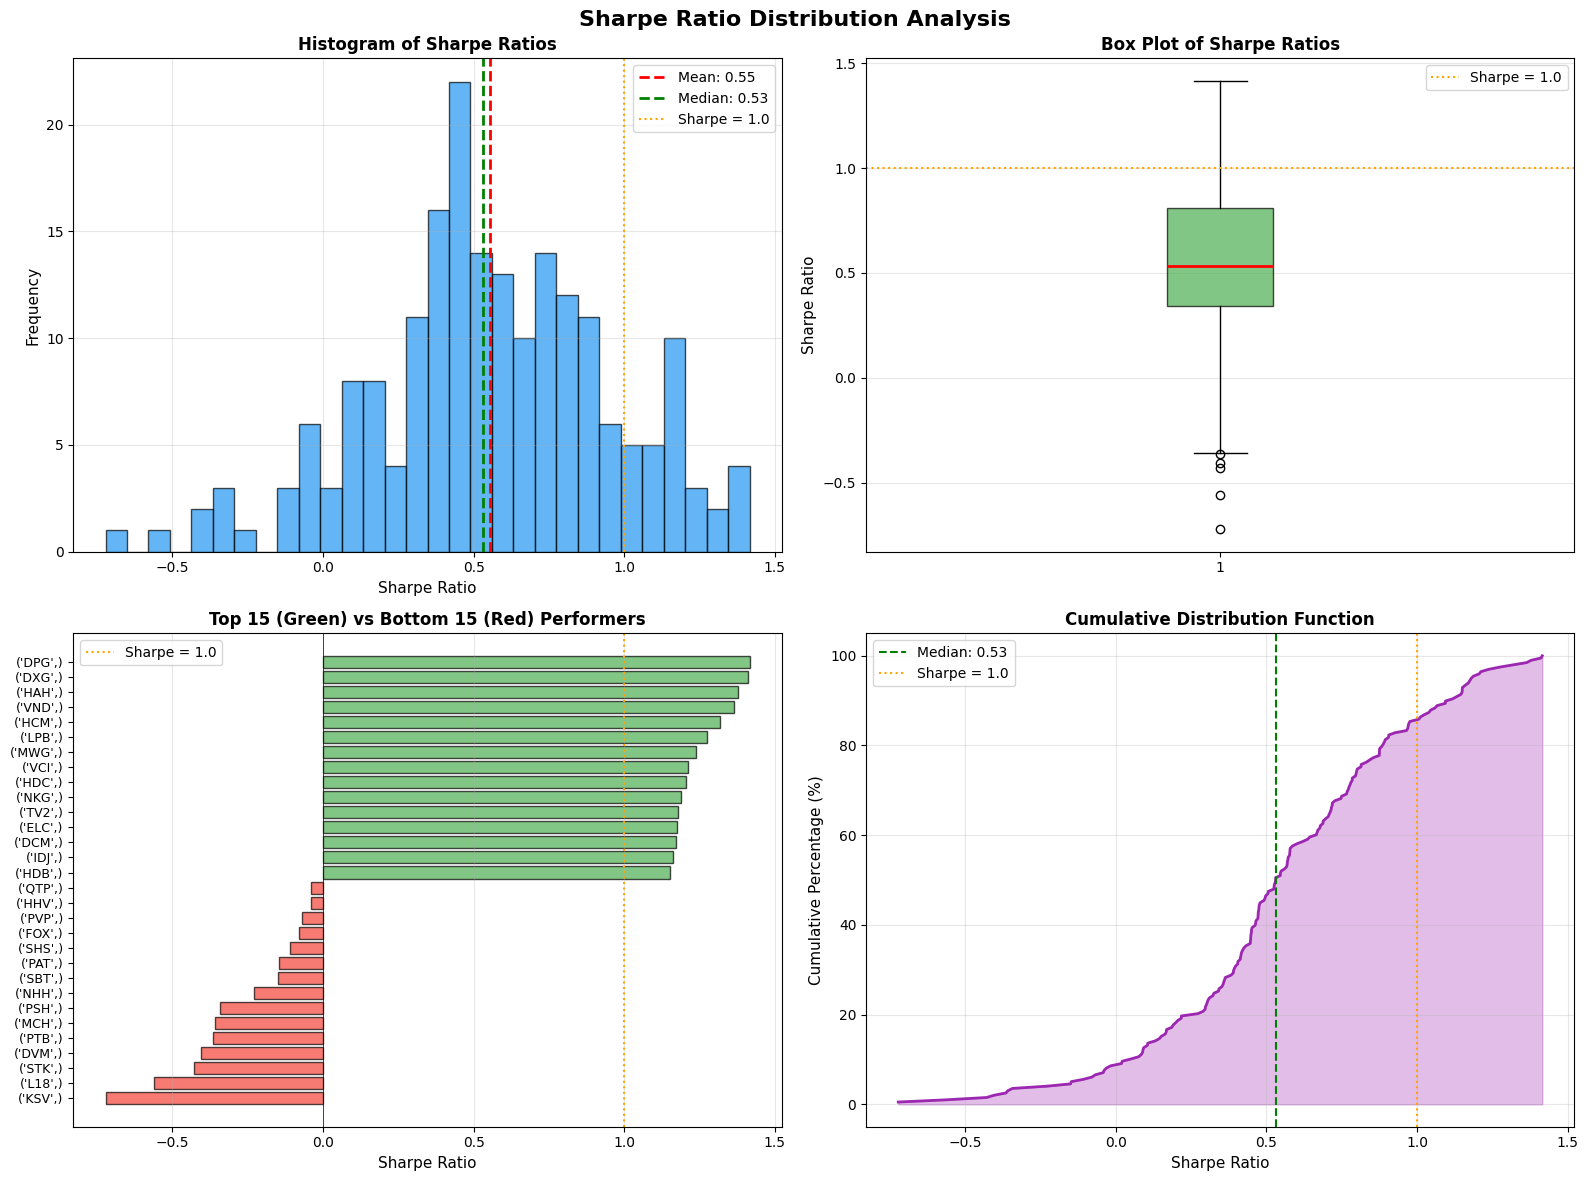


TOP 10 PERFORMERS (Highest Sharpe Ratio)
  ('NKG',):   1.187
  ('HDC',):   1.206
  ('VCI',):   1.212
  ('MWG',):   1.238
  ('LPB',):   1.275
  ('HCM',):   1.319
  ('VND',):   1.364
  ('HAH',):   1.379
  ('DXG',):   1.412
  ('DPG',):   1.416

BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)
  ('KSV',):  -0.721
  ('L18',):  -0.560
  ('STK',):  -0.428
  ('DVM',):  -0.404
  ('PTB',):  -0.364
  ('MCH',):  -0.358
  ('PSH',):  -0.343
  ('NHH',):  -0.228
  ('SBT',):  -0.150
  ('PAT',):  -0.147


In [51]:
# Extract and plot Sharpe ratio distribution for each symbol
import matplotlib.pyplot as plt
import seaborn as sns

pf_best = strategy_breakout_ttm(close, high, low, best_params)
# Get stats grouped by symbol
sharpe_ratios = pf_best.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
print(f"Sharpe Ratio Statistics:")
print(f"  Mean: {sharpe_ratios.mean():.3f}")
print(f"  Median: {sharpe_ratios.median():.3f}")
print(f"  Std: {sharpe_ratios.std():.3f}")
print(f"  Min: {sharpe_ratios.min():.3f}")
print(f"  Max: {sharpe_ratios.max():.3f}")
print(f"\nSymbols with Sharpe > 0.5: {(sharpe_ratios > 0.5).sum()}")
print(f"Symbols with Sharpe > 1.0: {(sharpe_ratios > 1.0).sum()}")

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sharpe Ratio Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Histogram
ax1 = axes[0, 0]
ax1.hist(sharpe_ratios.values, bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
ax1.axvline(sharpe_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sharpe_ratios.mean():.2f}')
ax1.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {sharpe_ratios.median():.2f}')
ax1.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax1.set_xlabel('Sharpe Ratio', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram of Sharpe Ratios', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot
ax2 = axes[0, 1]
bp = ax2.boxplot(sharpe_ratios.values, vert=True, patch_artist=True, 
                 boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax2.set_ylabel('Sharpe Ratio', fontsize=11)
ax2.set_title('Box Plot of Sharpe Ratios', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top/Bottom performers bar chart
ax3 = axes[1, 0]
top_n = 15
top_symbols = sharpe_ratios.tail(top_n)
bottom_symbols = sharpe_ratios.head(top_n)
combined = pd.concat([bottom_symbols, top_symbols])
colors = ['#F44336'] * len(bottom_symbols) + ['#4CAF50'] * len(top_symbols)
ax3.barh(range(len(combined)), combined.values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels(combined.index, fontsize=9)
ax3.axvline(0, color='black', linewidth=0.5)
ax3.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Top {top_n} (Green) vs Bottom {top_n} (Red) Performers', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4. Cumulative distribution
ax4 = axes[1, 1]
sorted_sharpe = np.sort(sharpe_ratios.values)
cumulative_pct = np.arange(1, len(sorted_sharpe) + 1) / len(sorted_sharpe) * 100
ax4.plot(sorted_sharpe, cumulative_pct, linewidth=2, color='#9C27B0')
ax4.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {sharpe_ratios.median():.2f}')
ax4.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax4.fill_between(sorted_sharpe, cumulative_pct, alpha=0.3, color='#9C27B0')
ax4.set_xlabel('Sharpe Ratio', fontsize=11)
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax4.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print top and bottom performers
print("\n" + "="*70)
print("TOP 10 PERFORMERS (Highest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.tail(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

print("\n" + "="*70)
print("BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.head(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

In [54]:
symbol = 'VGC'
# df1 = pd.DataFrame(pf[symbol].trades.records_readable)
# df1

df2 = pd.DataFrame(pf[symbol].stats())
df2

,VGC
Start,2016-01-29 00:00:00
End,2026-01-27 00:00:00
Period,2498 days 00:00:00
Start Value,100.0
End Value,253.352385
Total Return [%],153.352385
Benchmark Return [%],777.192982
Max Gross Exposure [%],100.0
Total Fees Paid,0.0
Max Drawdown [%],48.869011
